<a href="https://colab.research.google.com/github/shreya1110-dev/MTechCodeFiles/blob/main/Assignments/Sem2/NLP/NLP_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import zipfile
from pathlib import Path
import math
from collections import Counter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import copy

#Dataset

In [10]:
zip_path = "./wikitext-2-raw-v1.zip"
extract_dir = "wikitext2-raw"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

def convert_tokens_to_txt(src_path, dst_path):
    with open(src_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    with open(dst_path, "w", encoding="utf-8") as f:
        for line in lines:
            line = line.rstrip("\n")
            if line:
                f.write(line + " <eos>\n")
            else:
                f.write("<eos>\n")

convert_tokens_to_txt(f"{extract_dir}/wikitext-2-raw/wiki.train.raw", "/content/train.txt")
convert_tokens_to_txt(f"{extract_dir}/wikitext-2-raw/wiki.valid.raw", "/content/valid.txt")
convert_tokens_to_txt(f"{extract_dir}/wikitext-2-raw/wiki.test.raw", "/content/test.txt")

In [11]:
def load_and_tokenize(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read().lower()
    return text.split()


def build_vocabulary(tokens, max_vocab_size=10000):
    counts = Counter(tokens)
    word_to_id = {"<pad>": 0, "<unk>": 1}
    id_to_word = {0: "<pad>", 1: "<unk>"}

    most_common = counts.most_common(max_vocab_size - 2)
    for idx, (word, _) in enumerate(most_common, start=2):
        word_to_id[word] = idx
        id_to_word[idx] = word

    return word_to_id, id_to_word


def encode_tokens(tokens, word_to_id):
    unk = word_to_id["<unk>"]
    return [word_to_id.get(tok, unk) for tok in tokens]


def create_sliding_windows(token_ids, sequence_length=3):
    X, y = [], []
    for i in range(len(token_ids) - sequence_length):
        X.append(token_ids[i:i + sequence_length])
        y.append(token_ids[i + sequence_length])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

In [12]:
class WordDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [13]:
class WordPredictorLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out[:, -1, :])

In [14]:
def train_model(model, train_loader, val_loader, pad_idx, epochs=10, lr=1e-3, device="cpu", patience=2):
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_ppls = []

    best_val_ppl = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss_sum = 0.0
        train_batches = 0

        for Xb, yb in train_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_batches += 1

        avg_train_loss = train_loss_sum / max(train_batches, 1)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss_sum = 0.0
        val_batches = 0

        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(device)
                yb = yb.to(device)
                logits = model(Xb)
                loss = criterion(logits, yb)
                val_loss_sum += loss.item()
                val_batches += 1

        avg_val_loss = val_loss_sum / max(val_batches, 1)
        val_ppl = math.exp(avg_val_loss)
        val_ppls.append(val_ppl)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val PPL: {val_ppl:.4f}")

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"  New best model saved (Val PPL: {best_val_ppl:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience {patience_counter}/{patience}")

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_ppls, best_val_ppl

In [15]:
def plot_curves(train_losses, val_ppls):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, marker="o")
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_ppls, marker="o", color="red")
    plt.title("Validation Perplexity")
    plt.xlabel("Epoch")
    plt.ylabel("PPL")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [16]:
def predict_next_words(model, prompt, word_to_id, id_to_word, top_k=3, device="cpu"):
    model.eval()
    tokens = prompt.lower().split() or ["<unk>"]
    unk = word_to_id["<unk>"]
    ids = [word_to_id.get(tok, unk) for tok in tokens]
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(x)[0], dim=-1)
        top_probs, top_ids = torch.topk(probs, k=top_k)

    return [(id_to_word[idx.item()], float(p)) for p, idx in zip(top_probs, top_ids)]

Loading and tokenizing train.txt...
Using tokens: 2088628
Building vocabulary...
Vocab size: 10000
Encoding and creating windows...
Samples: 2088625
Max id: 9999 Vocab size: 10000
Training on: cuda
Epoch 1/10 | Train Loss: 5.2819 | Val PPL: 197.3560
  New best model saved (Val PPL: 197.3560)
Epoch 2/10 | Train Loss: 4.7484 | Val PPL: 187.1271
  New best model saved (Val PPL: 187.1271)
Epoch 3/10 | Train Loss: 4.5167 | Val PPL: 190.1376
  No improvement. Patience 1/2
Epoch 4/10 | Train Loss: 4.3546 | Val PPL: 197.7089
  No improvement. Patience 2/2
Early stopping triggered.


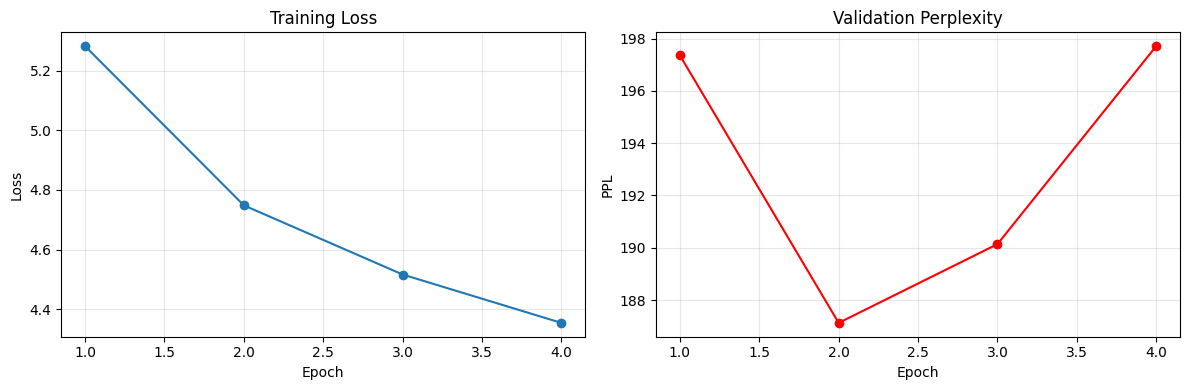


Prompt: 'the'
  <unk>  (p = 0.0358)
  song  (p = 0.0095)
  first  (p = 0.0087)

Prompt: 'in the'
  <unk>  (p = 0.0633)
  united  (p = 0.0241)
  area  (p = 0.0168)

Prompt: 'the cat'
  <unk>  (p = 0.0770)
  and  (p = 0.0732)
  ,  (p = 0.0602)

Prompt: 'this is'
  a  (p = 0.0961)
  the  (p = 0.0691)
  <unk>  (p = 0.0352)


In [18]:
def main():
    print("Loading and tokenizing train.txt...")
    tokens = load_and_tokenize("train.txt")
    tokens = tokens
    print("Using tokens:", len(tokens))

    print("Building vocabulary...")
    word_to_id, id_to_word = build_vocabulary(tokens, max_vocab_size=10000)
    vocab_size = len(word_to_id)
    print("Vocab size:", vocab_size)

    print("Encoding and creating windows...")
    token_ids = encode_tokens(tokens, word_to_id)
    X, y = create_sliding_windows(token_ids, sequence_length=3)
    print("Samples:", len(X))
    print("Max id:", int(X.max().item()), "Vocab size:", vocab_size)

    split_idx = int(0.9 * len(X))
    train_ds = WordDataset(X[:split_idx], y[:split_idx])
    val_ds = WordDataset(X[split_idx:], y[split_idx:])

    train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    model = WordPredictorLSTM(
        vocab_size=vocab_size,
        embedding_dim=128,
        hidden_dim=256,
        num_layers=1,
        pad_idx=word_to_id["<pad>"]
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Training on:", device)

    model, train_losses, val_ppls, best_val_ppl = train_model(
    model,
    train_loader,
    val_loader,
    pad_idx=word_to_id["<pad>"],
    epochs=10,
    lr=1e-3,
    device=device,
    patience=2
)

    plot_curves(train_losses, val_ppls)

    for prompt in ["the", "in the", "the cat", "this is"]:
        preds = predict_next_words(model, prompt, word_to_id, id_to_word, top_k=3, device=device)
        print(f"\nPrompt: '{prompt}'")
        for w, p in preds:
            print(f"  {w}  (p = {p:.4f})")

    return model, word_to_id, id_to_word, train_losses, val_ppls

if __name__ == "__main__":
    model, word_to_id, id_to_word, train_losses, val_ppls = main()